# RFM Segmentation — 11 Segments

This notebook implements the **Putler RFM methodology**: score every customer 1–5 on Recency, Frequency, and Monetary, then combine those scores into 11 named business segments.

Why is this better than simple K-Means?

- K-Means with K=4 gives you 4 blunt groups whose meaning you have to reverse-engineer
- RFM scoring gives you 11 actionable segments with names, descriptions, and strategies already built in
- The same methodology is used by banks, e-commerce companies, and CRM platforms worldwide

**File needed:** `credit_card_transactions.csv`

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('ggplot')
print('Imports done.')

Imports done.


## Step 2 — Load the data

In [2]:
df = pd.read_csv('credit_card_transactions.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print('Rows loaded:', len(df))
print('Columns:', df.columns.tolist())

Rows loaded: 1296675
Columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


## Step 3 — Parse dates and create age column

In [3]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob']                   = pd.to_datetime(df['dob'], errors='coerce')
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
print('Date columns ready.')

Date columns ready.


## Step 4 — Remove outliers (IQR method)

Remove extreme values from amount, age, and city population to prevent them distorting the scores.

In [4]:
for col in ['amt', 'age', 'city_pop']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print('Rows after outlier removal:', len(df))
print('Unique customers          :', df['cc_num'].nunique())

Rows after outlier removal: 1000070
Unique customers          : 781


## Step 5 — Collapse 1.3M rows into one row per customer

For each customer we calculate:
- **Recency** — how many days since their last transaction (lower = better)
- **Frequency** — total number of transactions (higher = better)
- **Monetary** — total amount spent (higher = better)
- Extra columns for fraud rate and spend analysis

In [5]:
ref_date = df['trans_date_trans_time'].max() + pd.Timedelta(days=1)

rfm = df.groupby('cc_num').agg(
    Recency    = ('trans_date_trans_time', lambda x: (ref_date - x.max()).days),
    Frequency  = ('trans_num',  'count'),
    Monetary   = ('amt',        'sum'),
    Avg_Amt    = ('amt',        'mean'),
    Fraud_Rate = ('is_fraud',   'mean'),
).reset_index()

print('Customer table shape:', rfm.shape)
rfm.head()

Customer table shape: (781, 6)


,cc_num,Recency,Frequency,Monetary,Avg_Amt,Fraud_Rate
0,60416207185,1,1476,63779.80,43.211247,0.004065
1,60422928733,1,1459,76538.87,52.459815,0.001371
2,60423098130,3,489,22848.04,46.724008,0.010225
3,60427851591,2,494,38768.06,78.477854,0.002024
4,60490596305,1,958,47932.06,50.033466,0.001044


## Step 6 — Assign RFM Scores (1 to 5)

This is the core of the Putler methodology.

We divide customers into **5 equal groups** (quintiles) for each of R, F, M:

- **R score:** 5 = most recent, 1 = least recent (note: low recency days = high score)
- **F score:** 5 = most frequent, 1 = least frequent
- **M score:** 5 = highest spend, 1 = lowest spend

We use `pd.qcut` with `rank(method='first')` to handle ties cleanly.

In [6]:
# Recency: lower days = better = higher score (labels reversed)
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'),   q=5, labels=[5,4,3,2,1]).astype(int)

# Frequency: higher = better = higher score
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

# Monetary: higher = better = higher score
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

# Combined score (sum of all three, range 3–15)
rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# FM combined (average of F and M — keeps 1–5 scale)
rfm['FM_score'] = (rfm['F_score'] + rfm['M_score']) / 2

print('Score distributions:')
print(rfm[['R_score','F_score','M_score']].describe().round(2))

Score distributions:
       R_score  F_score  M_score
count   781.00   781.00   781.00
mean      3.00     3.00     3.00
std       1.42     1.42     1.42
min       1.00     1.00     1.00
25%       2.00     2.00     2.00
50%       3.00     3.00     3.00
75%       4.00     4.00     4.00
max       5.00     5.00     5.00


## Step 7 — Check score distribution

Each score (1–5) should have roughly equal numbers of customers — because we used quintiles. This is a sanity check.

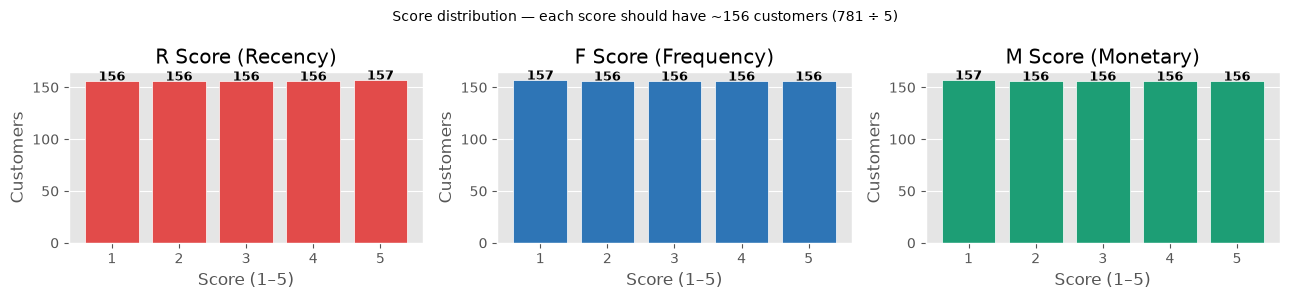

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, col, label, color in zip(
    axes,
    ['R_score','F_score','M_score'],
    ['R Score (Recency)','F Score (Frequency)','M Score (Monetary)'],
    ['#E24B4A','#2E75B6','#1D9E75']
):
    vc = rfm[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Score (1–5)')
    ax.set_ylabel('Customers')
    ax.set_xticks([1,2,3,4,5])
    for xi, yi in zip(vc.index, vc.values):
        ax.text(xi, yi + 0.5, str(yi), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Score distribution — each score should have ~156 customers (781 ÷ 5)', fontsize=10)
plt.tight_layout()
plt.show()

## Step 8 — Assign segments

This is the segment mapping from the Putler RFM framework. It uses **R score** and **FM score** (average of F and M) to place each customer into one of 11 named segments.

| Segment | R Score | FM Score |
|---|---|---|
| 🏆 Champions | 4–5 | 4–5 |
| 💙 Loyal Customers | 3–5 | 3–5 |
| 🌱 Potential Loyalist | 4–5 | 1–3 |
| 🆕 New Customers | 4–5 | ≤2 |
| ⭐ Promising | 3 | ≤2 |
| ⚠️ Needs Attention | 2–3 | 2–3 |
| 😴 About To Sleep | 2–3 | ≤2 |
| 🚨 At Risk | 1–2 | 3–5 |
| 🔒 Cannot Lose Them | 1 | 4–5 |
| ❄️ Hibernating | 1–2 | 1–2 |
| 💔 Lost | 1–2 | 1 |

In [8]:
def assign_segment(r, fm):
    """Map R score + FM score to one of 11 named segments."""
    if   r >= 4 and fm >= 4:           return 'Champions'
    elif r <= 1 and fm >= 4:           return 'Cannot Lose Them'
    elif r <= 2 and fm >= 3:           return 'At Risk'
    elif r >= 3 and fm >= 3:           return 'Loyal Customers'
    elif r >= 4 and fm < 2:            return 'New Customers'
    elif r == 3 and fm < 2:            return 'Promising'
    elif 2 <= r <= 3 and 2 <= fm <= 3: return 'Needs Attention'
    elif 2 <= r <= 3 and fm < 2:       return 'About To Sleep'
    elif 1 <= r <= 2 and 1 <= fm <= 2: return 'Hibernating'
    elif r <= 2 and fm < 1:            return 'Lost'
    else:                              return 'Hibernating'

rfm['Segment'] = rfm.apply(lambda row: assign_segment(row['R_score'], row['FM_score']), axis=1)

print('Customers per segment:')
print(rfm['Segment'].value_counts().to_string())

Customers per segment:
Segment
Loyal Customers     176
Hibernating         174
Champions           133
At Risk             115
Needs Attention      71
New Customers        50
Promising            28
About To Sleep       21
Cannot Lose Them     13


## Step 9 — Segment profiles

For each segment, show the average R, F, M scores and actual customer numbers.

In [9]:
profile = rfm.groupby('Segment').agg(
    Customers       = ('cc_num',    'count'),
    Avg_R_score     = ('R_score',   'mean'),
    Avg_F_score     = ('F_score',   'mean'),
    Avg_M_score     = ('M_score',   'mean'),
    Avg_RFM         = ('RFM_Score', 'mean'),
    Median_Recency  = ('Recency',   'median'),
    Median_Freq     = ('Frequency', 'median'),
    Median_Monetary = ('Monetary',  'median'),
    Avg_Fraud_Rate  = ('Fraud_Rate','mean'),
).round(2).sort_values('Avg_RFM', ascending=False)

print(profile.to_string())

                  Customers  Avg_R_score  Avg_F_score  Avg_M_score  Avg_RFM  Median_Recency  Median_Freq  Median_Monetary  Avg_Fraud_Rate
Segment                                                                                                                                  
Champions               133         4.53         4.53         4.59    13.65             1.0       1980.0        101509.74            0.00
Loyal Customers         176         3.64         3.66         3.71    11.01             1.0       1477.0         74629.46            0.00
Cannot Lose Them         13         1.00         4.46         4.46     9.92             1.0       1974.0         96895.78            0.00
At Risk                 115         1.83         4.03         3.98     9.84             1.0       1524.0         83610.43            0.00
New Customers            50         4.60         1.28         1.22     7.10             1.0        490.5         23845.94            0.00
Needs Attention          71       

## Step 10 — Visualise: Customer count per segment

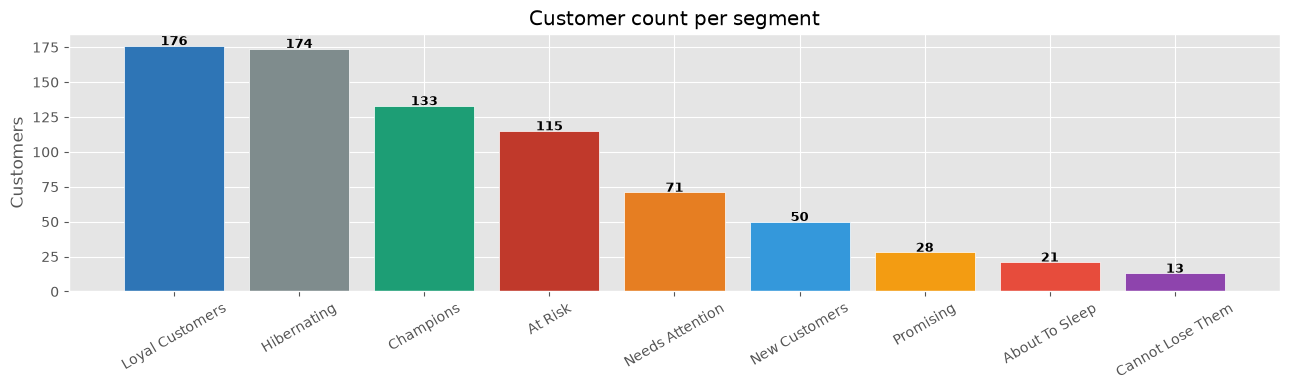

In [10]:
COLORS = {
    'Champions':          '#1D9E75',
    'Loyal Customers':    '#2E75B6',
    'Potential Loyalist': '#27AE60',
    'New Customers':      '#3498DB',
    'Promising':          '#F39C12',
    'Needs Attention':    '#E67E22',
    'About To Sleep':     '#E74C3C',
    'At Risk':            '#C0392B',
    'Cannot Lose Them':   '#8E44AD',
    'Hibernating':        '#7F8C8D',
    'Lost':               '#95A5A6',
}

counts = rfm['Segment'].value_counts()
bar_colors = [COLORS.get(s, '#888') for s in counts.index]

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white')
ax.set_ylabel('Customers')
ax.set_title('Customer count per segment')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11 — Visualise: R × FM scatter plot

This shows where each customer sits on the Recency vs FM score grid. Champions should be top-right. Hibernating/Lost should be bottom-left.

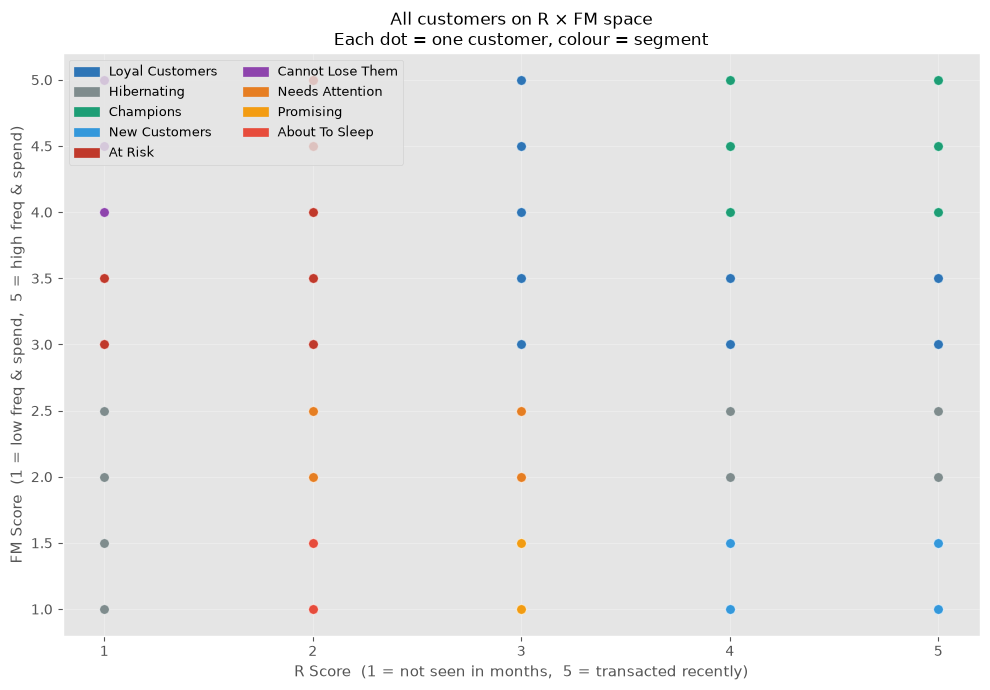

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

for seg in rfm['Segment'].unique():
    sub = rfm[rfm['Segment'] == seg]
    ax.scatter(sub['R_score'], sub['FM_score'],
               c=COLORS.get(seg, '#888'), label=seg, alpha=0.65, s=45,
               edgecolors='white', linewidths=0.3)

ax.set_xlabel('R Score  (1 = not seen in months,  5 = transacted recently)', fontsize=11)
ax.set_ylabel('FM Score  (1 = low freq & spend,  5 = high freq & spend)', fontsize=11)
ax.set_title('All customers on R × FM space\nEach dot = one customer, colour = segment', fontsize=12)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
ax.grid(True, alpha=0.3)

legend_patches = [mpatches.Patch(color=COLORS.get(s,'#888'), label=s) for s in rfm['Segment'].unique()]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

## Step 12 — Visualise: Segment profiles — R, F, M scores side by side

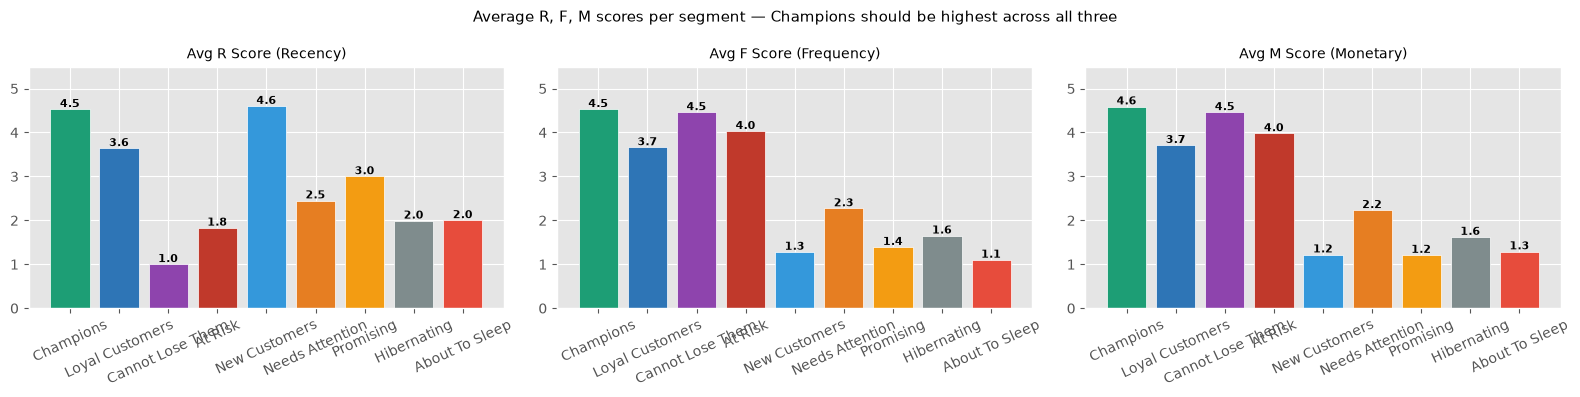

In [12]:
seg_order = profile.sort_values('Avg_RFM', ascending=False).index.tolist()
bc = [COLORS.get(s,'#888') for s in seg_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(
    axes,
    ['Avg_R_score','Avg_F_score','Avg_M_score'],
    ['Avg R Score (Recency)','Avg F Score (Frequency)','Avg M Score (Monetary)']
):
    vals = [profile.loc[s, col] for s in seg_order]
    bars = ax.bar(seg_order, vals, color=bc, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylim(0, 5.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Average R, F, M scores per segment — Champions should be highest across all three', fontsize=11)
plt.tight_layout()
plt.show()

## Step 13 — Visualise: Actual customer numbers per segment (Recency, Frequency, Monetary)

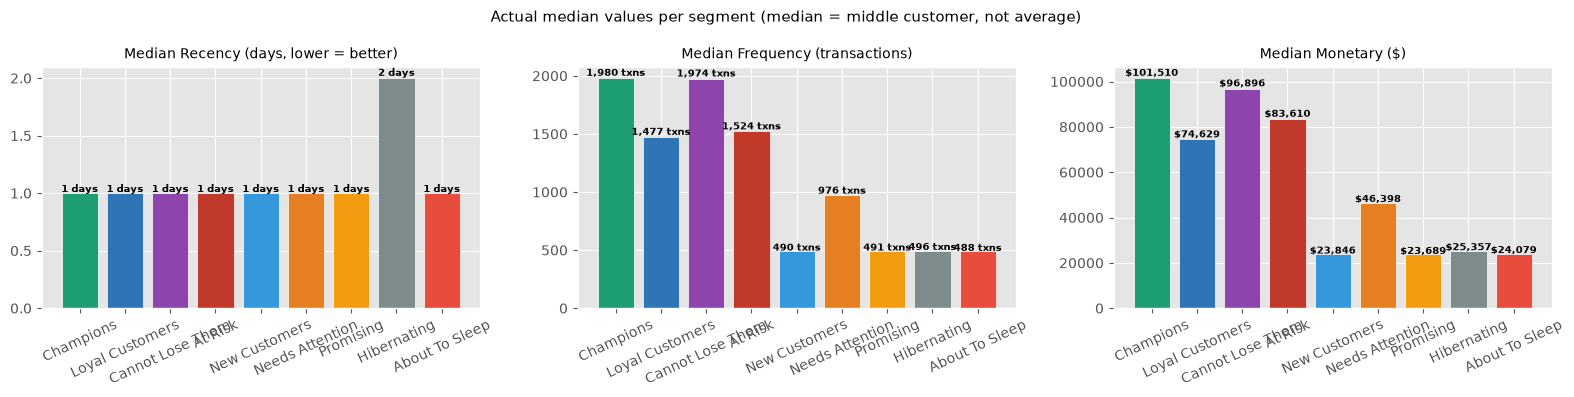

In [13]:
actual = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].median().reindex(seg_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title, fmt in zip(
    axes,
    ['Recency','Frequency','Monetary'],
    ['Median Recency (days, lower = better)',
     'Median Frequency (transactions)',
     'Median Monetary ($)'],
    ['{:.0f} days', '{:,.0f} txns', '${:,.0f}']
):
    vals = [actual.loc[s, col] for s in seg_order]
    bars = ax.bar(seg_order, vals, color=bc, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt.format(v), ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Actual median values per segment (median = middle customer, not average)', fontsize=11)
plt.tight_layout()
plt.show()

## Step 14 — Fraud rate by segment

An interesting business insight: do certain segments have higher fraud rates?

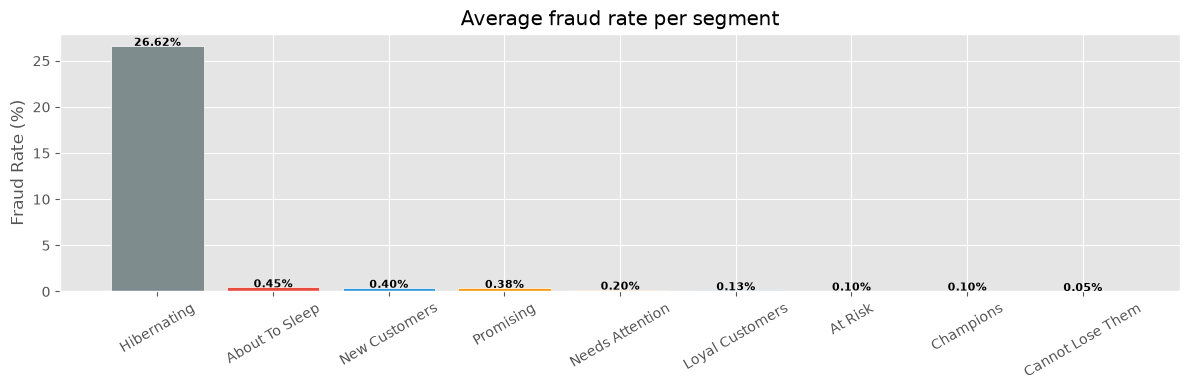


Fraud rate per segment:
  Hibernating            26.62%  (174 customers)
  About To Sleep         0.45%  (21 customers)
  New Customers          0.40%  (50 customers)
  Promising              0.38%  (28 customers)
  Needs Attention        0.20%  (71 customers)
  Loyal Customers        0.13%  (176 customers)
  At Risk                0.10%  (115 customers)
  Champions              0.10%  (133 customers)
  Cannot Lose Them       0.05%  (13 customers)


In [14]:
fraud_order = rfm.groupby('Segment')['Fraud_Rate'].mean().sort_values(ascending=False).index.tolist()
fraud_vals  = rfm.groupby('Segment')['Fraud_Rate'].mean().reindex(fraud_order) * 100
fraud_colors = [COLORS.get(s,'#888') for s in fraud_order]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(fraud_order, fraud_vals, color=fraud_colors, edgecolor='white')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Average fraud rate per segment')
ax.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, fraud_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.2f}%', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFraud rate per segment:')
for s in fraud_order:
    r = rfm[rfm['Segment']==s]['Fraud_Rate'].mean() * 100
    n = (rfm['Segment']==s).sum()
    print(f'  {s:<22} {r:.2f}%  ({n} customers)')

## Step 15 — Segment business descriptions

What each segment means and what action the bank should take.

In [15]:
SEGMENT_META = {
    'Champions':          ('Bought recently, transact often, spend the most.',
                           'Reward them. Give early access to new products. They will refer others.'),
    'Loyal Customers':    ('Spend well and transact often. Responsive to offers.',
                           'Upsell higher-value products. Ask for referrals. Keep engaged.'),
    'Potential Loyalist': ('Active recently but frequency and spend are still growing.',
                           'Offer a loyalty program. Recommend products they have not tried yet.'),
    'New Customers':      ('Bought most recently but not yet frequent.',
                           'Onboard well. Give early wins. Build the relationship.'),
    'Promising':          ('Recent activity but spend is still low.',
                           'Show them what they are missing. Build brand awareness.'),
    'Needs Attention':    ('Average scores across all three dimensions.',
                           'Limited-time offers. Recommend based on past behaviour. Reactivate.'),
    'About To Sleep':     ('Below average recency, frequency, and spend. Fading.',
                           'Send a win-back campaign. Offer a discount or bonus.'),
    'At Risk':            ('Used to transact a lot but have gone quiet recently.',
                           'Personalised outreach. Remind them of what they loved. Act now.'),
    'Cannot Lose Them':   ('Made big purchases often but disappeared completely.',
                           'Immediate personal contact. Top priority. Do not lose to a competitor.'),
    'Hibernating':        ('Last purchase was long ago. Low frequency and spend.',
                           'Try a relevant discount. Low investment — last attempt.'),
    'Lost':               ('Lowest scores on all three dimensions.',
                           'Minimal effort. One last campaign. Accept if no response.'),
}

print('=' * 65)
print('SEGMENT DESCRIPTIONS AND BANK ACTIONS')
print('=' * 65)
counts_dict = rfm['Segment'].value_counts().to_dict()
for seg, (desc, action) in SEGMENT_META.items():
    n = counts_dict.get(seg, 0)
    print(f'\n{seg} ({n} customers)')
    print(f'  What they look like: {desc}')
    print(f'  Bank action:         {action}')

SEGMENT DESCRIPTIONS AND BANK ACTIONS

Champions (133 customers)
  What they look like: Bought recently, transact often, spend the most.
  Bank action:         Reward them. Give early access to new products. They will refer others.

Loyal Customers (176 customers)
  What they look like: Spend well and transact often. Responsive to offers.
  Bank action:         Upsell higher-value products. Ask for referrals. Keep engaged.

Potential Loyalist (0 customers)
  What they look like: Active recently but frequency and spend are still growing.
  Bank action:         Offer a loyalty program. Recommend products they have not tried yet.

New Customers (50 customers)
  What they look like: Bought most recently but not yet frequent.
  Bank action:         Onboard well. Give early wins. Build the relationship.

Promising (28 customers)
  What they look like: Recent activity but spend is still low.
  Bank action:         Show them what they are missing. Build brand awareness.

Needs Attention (71 cu

## Step 16 — Save output

Save the customer table with segments attached. This file is read by the dashboard.

In [16]:
rfm.to_csv('cc_kmeans_output.csv', index=False)
print('Saved: cc_kmeans_output.csv')
print('Columns:', rfm.columns.tolist())
print('Rows:',    len(rfm))
print()
print('Final segment counts:')
print(rfm['Segment'].value_counts().to_string())

Saved: cc_kmeans_output.csv
Columns: ['cc_num', 'Recency', 'Frequency', 'Monetary', 'Avg_Amt', 'Fraud_Rate', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'FM_score', 'Segment']
Rows: 781

Final segment counts:
Segment
Loyal Customers     176
Hibernating         174
Champions           133
At Risk             115
Needs Attention      71
New Customers        50
Promising            28
About To Sleep       21
Cannot Lose Them     13


## Step 17 — Summary table

Print the full segment summary with real numbers — this is what you show in a presentation.

In [17]:
summary = rfm.groupby('Segment').agg(
    Customers       = ('cc_num',    'count'),
    Avg_R           = ('R_score',   'mean'),
    Avg_F           = ('F_score',   'mean'),
    Avg_M           = ('M_score',   'mean'),
    Avg_RFM_Score   = ('RFM_Score', 'mean'),
    Med_Recency_days= ('Recency',   'median'),
    Med_Frequency   = ('Frequency', 'median'),
    Med_Monetary_USD= ('Monetary',  'median'),
    Avg_Fraud_Rate  = ('Fraud_Rate','mean'),
).round(2).sort_values('Avg_RFM_Score', ascending=False)

print('COMPLETE SEGMENT SUMMARY')
print(summary.to_string())

COMPLETE SEGMENT SUMMARY
                  Customers  Avg_R  Avg_F  Avg_M  Avg_RFM_Score  Med_Recency_days  Med_Frequency  Med_Monetary_USD  Avg_Fraud_Rate
Segment                                                                                                                           
Champions               133   4.53   4.53   4.59          13.65               1.0         1980.0         101509.74            0.00
Loyal Customers         176   3.64   3.66   3.71          11.01               1.0         1477.0          74629.46            0.00
Cannot Lose Them         13   1.00   4.46   4.46           9.92               1.0         1974.0          96895.78            0.00
At Risk                 115   1.83   4.03   3.98           9.84               1.0         1524.0          83610.43            0.00
New Customers            50   4.60   1.28   1.22           7.10               1.0          490.5          23845.94            0.00
Needs Attention          71   2.45   2.27   2.23          